In [1]:
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import train_test_split


import src.data.utils as dutils
from src.models.neural import CNNv01

In [2]:
PATH = "../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/"
comb_df, test_df = dutils.read_data_v2(PATH)

with open("../configs/base_config.yaml", 'r') as f:
    base_config = yaml.safe_load(f)

comb_df.shape, test_df.shape

C:\Work\Project\cv-architecture-sprint-cifar\src\data\utils.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


((50000, 3), (10000, 3))

In [3]:
torch.manual_seed(base_config["base"]["random_state"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
X = comb_df["data"]; y = comb_df["label"]
X_test = test_df["data"]; y_test = test_df["label"]
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=base_config["base"]["val_split"], 
                                                  random_state=base_config["base"]["random_state"], 
                                                  stratify=y)


print("Train size: ", X_train.shape, y_train.shape)
print("Test size: ", X_test.shape, y_test.shape)
print("Val size: ", X_val.shape, y_val.shape)

Train size:  (40000,) (40000,)
Test size:  (10000,) (10000,)
Val size:  (10000,) (10000,)


In [5]:
train_df = pl.DataFrame({"data": X_train, "label": y_train})
val_df = pl.DataFrame({"data": X_val, "label": y_val})

train_df.shape, val_df.shape

((40000, 2), (10000, 2))

In [6]:
train_dataset = dutils.CIFARData(train_df)
test_dataset = dutils.CIFARData(test_df)
val_dataset = dutils.CIFARData(val_df)

train_loader = DataLoader(train_dataset, 
                         batch_size=base_config["neural"]["train_batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)
test_loader = DataLoader(test_dataset, 
                        batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [7]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

val_tf = transforms.Compose([
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

In [8]:
net = CNNv01(
    input_dim= 32 * 32 * 3,
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1,10 + 1), total=10):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = train_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        
        logit = net(_data)
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"]
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 3, 32, 32))
            _data = _data / 255.0
            _data = val_tf(_data)
            _data = _data.to(base_config["base"]["gpu"])
            
            logit = net(_data)
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history["train_loss"].append(train_loss.detach().cpu().numpy())
    history["val_loss"].append(val_loss.detach().cpu().numpy())
    history["cm"].append(cm)

  0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 1250/1250 [00:08<00:00, 154.85it/s]


Training loss on epoch: 1: 1.9157112836837769


 10%|█         | 1/10 [00:19<02:56, 19.62s/it]

Val loss on epoch: 1: 1.6654731035232544
[[447  65  27  31  13   7  16  46 227 121]
 [ 32 500  15  13   2  11  30  25 129 243]
 [121  69 275  61  90  35 118 131  59  41]
 [ 53  38  96 208  30 167 187  69  54  98]
 [ 65  26 160  35 209  18 116 247  66  58]
 [ 51  43 115 141  37 261 126 115  56  55]
 [ 20  22 135  40 119  40 463  85  34  42]
 [ 49  56  62  41  32  42  48 498  38 134]
 [120  63   4  20   6  10  11  14 625 127]
 [ 29 169  13  19   2  16  29  31 149 543]]


...

Val loss on epoch: 9: 1.4506959915161133
[[553  88  13  19  20   7  25  50 152  73]
 [ 33 619   5  12   9   5  17  27  81 192]
 [143  28 227  91 126  28 125 142  41  49]
 [ 71  35  69 344  32 115 141  91  29  73]
 [ 87  11  73  68 348   8 118 197  51  39]
 [ 61  37  73 246  42 222  97 135  38  49]
 [ 42  14  45  95  81  13 592  67  14  37]
 [ 52  32  24  53  46  22  28 640  20  83]
 [102  99   0  15   8  11   8  13 675  69]
 [ 36 208   8  22   6  14  14  33  80 579]]


Training: 100%|██████████| 1250/1250 [00:07<00:00, 167.81it/s]


Training loss on epoch: 10: 1.581598162651062


100%|██████████| 10/10 [03:03<00:00, 18.33s/it]

Val loss on epoch: 10: 1.4247851371765137
[[506  81  27  15  20   9  24  85 108 125]
 [ 23 608  13   7   5   7  18  22  48 249]
 [ 82  22 274  60 128  82 124 152  29  47]
 [ 31  28  71 219  32 226 165 127  28  73]
 [ 54  11  77  28 348  49 109 242  36  46]
 [ 32  30  67 127  32 371 104 142  31  64]
 [ 14  14  50  37  99  50 616  83   9  28]
 [ 21  28  28  22  32  50  30 694  15  80]
 [103  94   4  10   8  14   6  18 593 150]
 [ 16 164  11  21   5  12  16  61  40 654]]


In [11]:
net2 = CNNv01(
    input_dim= 32 * 32 * 3,
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net2.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [12]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history2 = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1, 30 + 1), total=30):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net2.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = train_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        
        logit = net2(_data)
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net2.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"]
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 3, 32, 32))
            _data = _data / 255.0
            _data = val_tf(_data)
            _data = _data.to(base_config["base"]["gpu"])
            
            logit = net2(_data)
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history2["train_loss"].append(train_loss.detach().cpu().numpy())
    history2["val_loss"].append(val_loss.detach().cpu().numpy())
    history2["cm"].append(cm)

Training: 100%|██████████| 1250/1250 [00:07<00:00, 162.95it/s]


Training loss on epoch: 1: 1.9296960830688477


  3%|▎         | 1/30 [00:19<09:15, 19.15s/it]

Val loss on epoch: 1: 1.6643553972244263
[[580  82  38  46  13   3  25  30  91  92]
 [ 64 539  12  28   7   3  29  22  80 216]
 [136  61 253  83 108  32 160  93  19  55]
 [ 49  50  67 334  35  77 222  67  17  82]
 [ 98  31 149  57 304   8 128 157  24  44]
 [ 62  38  82 264  71 152 154  93  30  54]
 [ 13  25 118  97 113  15 504  50  12  53]
 [ 95  74  62  61  65  23  47 453  17 103]
 [301  73   8  41  11   5  12  14 419 116]
 [ 88 221   9  47   6   7  28  33  88 473]]


Training: 100%|██████████| 1250/1250 [00:07<00:00, 169.93it/s]


...

Val loss on epoch: 29: 1.3615896701812744
[[621  71  23  26  19   6  29  40  80  85]
 [ 48 645   4  16   3   4  20  21  46 193]
 [ 83  23 323 111 100  38 109 146  19  48]
 [ 53  23  56 379  26 131 192  79  14  47]
 [ 84  16  90  64 342  19 121 197  25  42]
 [ 46  26  64 268  32 240 118 137  14  55]
 [ 12  14  48  60  85  19 691  43   6  22]
 [ 45  30  23  56  23  31  34 688   7  63]
 [154  95   6  23   8   7  12   8 582 105]
 [ 27 226   4  28   7   7  24  36  33 608]]


Training: 100%|██████████| 1250/1250 [00:07<00:00, 173.72it/s]


Training loss on epoch: 30: 1.5029141902923584


100%|██████████| 30/30 [08:59<00:00, 17.99s/it]

Val loss on epoch: 30: 1.3581205606460571
[[560  92  13  24  23  13  31  32 116  96]
 [ 36 663   3  18   6   3  15  14  56 186]
 [ 84  23 252 100 123  68 162 117  25  46]
 [ 29  25  52 353  27 178 207  63  17  49]
 [ 66  15  57  60 360  28 154 184  35  41]
 [ 32  27  34 215  42 342 124 116  25  43]
 [  9  19  24  61  91  30 691  38   7  30]
 [ 33  28  13  57  36  43  44 658  13  75]
 [106 111   5  21   8   5   9  10 625 100]
 [ 24 223   2  26   4  11  19  26  40 625]]


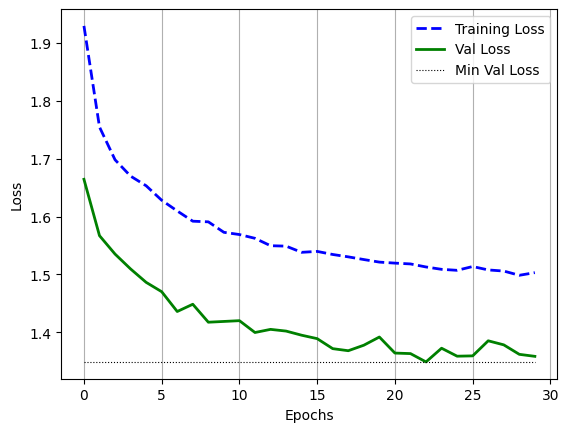

In [13]:
from src.utils import plot_neural
plot_neural(
    epochs= len(history2["train_loss"]), train_loss= history2["train_loss"], val_loss = history2["val_loss"]
)

In [14]:
import os

meta = os.path.join(PATH, "batches.meta")

metadata = dutils.read_pkl(meta)
label_name = [l.decode("utf-8") for l in metadata[b'label_names']]

In [15]:
from src.eval.metrics import format_cm, evaluate

In [16]:
y_test_v = []
y_test_pred = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v.extend(_label.cpu().numpy())
        y_test_pred.extend(y_pred.cpu().numpy())

cm = evaluate(y_test_v, y_test_pred)
format_cm(cm, class_names=label_name, normalize=True)


              precision    recall  f1-score   support

           0     0.5672    0.5400    0.5533      1000
           1     0.5789    0.6160    0.5969      1000
           2     0.4784    0.2990    0.3680      1000
           3     0.3968    0.2230    0.2855      1000
           4     0.4603    0.3300    0.3844      1000
           5     0.4363    0.3730    0.4022      1000
           6     0.4937    0.6260    0.5520      1000
           7     0.4258    0.6800    0.5237      1000
           8     0.6307    0.5960    0.6129      1000
           9     0.4565    0.6460    0.5350      1000

    accuracy                         0.4929     10000
   macro avg     0.4925    0.4929    0.4814     10000
weighted avg     0.4925    0.4929    0.4814     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.540,0.069,0.033,0.013,0.018,0.003,0.028,0.066,0.130,0.100
True: automobile,0.020,0.616,0.014,0.005,0.003,0.010,0.014,0.025,0.046,0.247
True: bird,0.089,0.029,0.299,0.052,0.126,0.085,0.124,0.135,0.021,0.040
True: cat,0.053,0.024,0.050,0.223,0.032,0.216,0.172,0.125,0.032,0.073
True: deer,0.059,0.009,0.082,0.032,0.330,0.038,0.145,0.245,0.031,0.029
True: dog,0.027,0.021,0.064,0.140,0.036,0.373,0.102,0.156,0.036,0.045
True: frog,0.006,0.010,0.049,0.036,0.118,0.038,0.626,0.078,0.013,0.026
True: horse,0.031,0.026,0.021,0.035,0.034,0.070,0.020,0.680,0.011,0.072
True: ship,0.100,0.081,0.005,0.012,0.011,0.015,0.015,0.028,0.596,0.137
True: truck,0.027,0.179,0.008,0.014,0.009,0.007,0.022,0.059,0.029,0.646


In [17]:
y_test_v2 = []
y_test_pred2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net2(_data)
        y_pred = logit.argmax(1)
        
        y_test_v2.extend(_label.cpu().numpy())
        y_test_pred2.extend(y_pred.cpu().numpy())

cm2 = evaluate(y_test_v2, y_test_pred2)
format_cm(cm2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.5520    0.5680    0.5599      1000
           1     0.5688    0.6700    0.6152      1000
           2     0.5723    0.2690    0.3660      1000
           3     0.3565    0.3230    0.3389      1000
           4     0.5046    0.3820    0.4348      1000
           5     0.4972    0.3580    0.4163      1000
           6     0.4740    0.7110    0.5688      1000
           7     0.5229    0.6270    0.5703      1000
           8     0.6434    0.6280    0.6356      1000
           9     0.4783    0.6050    0.5342      1000

    accuracy                         0.5141     10000
   macro avg     0.5170    0.5141    0.5040     10000
weighted avg     0.5170    0.5141    0.5040     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.568,0.069,0.019,0.032,0.016,0.001,0.036,0.028,0.141,0.090
True: automobile,0.026,0.670,0.003,0.014,0.008,0.007,0.012,0.017,0.052,0.191
True: bird,0.102,0.027,0.269,0.090,0.123,0.071,0.157,0.104,0.018,0.039
True: cat,0.049,0.022,0.028,0.323,0.039,0.163,0.214,0.082,0.018,0.062
True: deer,0.061,0.009,0.062,0.072,0.382,0.027,0.163,0.168,0.029,0.027
True: dog,0.035,0.020,0.039,0.214,0.038,0.358,0.126,0.112,0.020,0.038
True: frog,0.004,0.019,0.027,0.056,0.098,0.028,0.711,0.026,0.010,0.021
True: horse,0.045,0.022,0.016,0.062,0.033,0.047,0.048,0.627,0.014,0.086
True: ship,0.110,0.084,0.004,0.022,0.017,0.011,0.010,0.008,0.628,0.106
True: truck,0.029,0.236,0.003,0.021,0.003,0.007,0.023,0.027,0.046,0.605


In [18]:
test_df_shifted = test_df.with_columns(pl.Series("data",[dutils.shift_data(data_list) for data_list in test_df["data"].to_list()] )) 
test_shifted_dataset = dutils.CIFARData(test_df_shifted)
test_shifted_loader = DataLoader(test_shifted_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [19]:
y_test_v_shifted = []
y_test_pred_shifted = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v_shifted.extend(_label.cpu().numpy())
        y_test_pred_shifted.extend(y_pred.cpu().numpy())

cm_shifted = evaluate(y_test_v_shifted, y_test_pred_shifted)
format_cm(cm_shifted, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.6672    0.3890    0.4915      1000
           1     0.6047    0.4360    0.5067      1000
           2     0.4408    0.1860    0.2616      1000
           3     0.3363    0.2250    0.2696      1000
           4     0.4456    0.3480    0.3908      1000
           5     0.2962    0.5350    0.3813      1000
           6     0.4920    0.4890    0.4905      1000
           7     0.4673    0.5580    0.5087      1000
           8     0.5278    0.5610    0.5439      1000
           9     0.3928    0.6940    0.5016      1000

    accuracy                         0.4421     10000
   macro avg     0.4671    0.4421    0.4346     10000
weighted avg     0.4671    0.4421    0.4346     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.389,0.041,0.031,0.018,0.015,0.051,0.020,0.070,0.190,0.175
True: automobile,0.014,0.436,0.012,0.021,0.011,0.032,0.020,0.028,0.066,0.360
True: bird,0.064,0.021,0.186,0.070,0.130,0.237,0.117,0.097,0.029,0.049
True: cat,0.014,0.019,0.038,0.225,0.030,0.378,0.101,0.086,0.045,0.064
True: deer,0.027,0.007,0.056,0.046,0.348,0.147,0.142,0.139,0.043,0.045
True: dog,0.006,0.007,0.028,0.147,0.042,0.535,0.061,0.085,0.052,0.037
True: frog,0.006,0.007,0.042,0.070,0.129,0.171,0.489,0.041,0.014,0.031
True: horse,0.012,0.014,0.016,0.034,0.054,0.188,0.020,0.558,0.019,0.085
True: ship,0.042,0.058,0.005,0.018,0.011,0.038,0.010,0.030,0.561,0.227
True: truck,0.009,0.111,0.008,0.020,0.011,0.029,0.014,0.060,0.044,0.694


In [20]:
y_test_v_shifted2 = []
y_test_pred_shifted2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net2(_data)
        y_pred = logit.argmax(1)
        
        y_test_v_shifted2.extend(_label.cpu().numpy())
        y_test_pred_shifted2.extend(y_pred.cpu().numpy())

cm_shifted2 = evaluate(y_test_v_shifted2, y_test_pred_shifted2)
format_cm(cm_shifted2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.6717    0.4030    0.5038      1000
           1     0.6649    0.5060    0.5747      1000
           2     0.5643    0.1800    0.2729      1000
           3     0.2702    0.3980    0.3219      1000
           4     0.4903    0.3790    0.4275      1000
           5     0.3256    0.5450    0.4076      1000
           6     0.5324    0.5090    0.5204      1000
           7     0.6169    0.4670    0.5316      1000
           8     0.5615    0.6300    0.5938      1000
           9     0.4403    0.6890    0.5372      1000

    accuracy                         0.4706     10000
   macro avg     0.5138    0.4706    0.4691     10000
weighted avg     0.5138    0.4706    0.4691     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.403,0.026,0.019,0.071,0.019,0.061,0.021,0.022,0.202,0.156
True: automobile,0.010,0.506,0.004,0.051,0.003,0.030,0.019,0.012,0.089,0.276
True: bird,0.069,0.017,0.180,0.165,0.120,0.215,0.120,0.048,0.017,0.049
True: cat,0.012,0.014,0.021,0.398,0.023,0.335,0.076,0.030,0.028,0.063
True: deer,0.025,0.012,0.038,0.144,0.379,0.122,0.120,0.083,0.037,0.040
True: dog,0.002,0.007,0.017,0.238,0.033,0.545,0.050,0.051,0.017,0.040
True: frog,0.002,0.010,0.023,0.209,0.104,0.092,0.509,0.018,0.013,0.020
True: horse,0.020,0.013,0.008,0.107,0.067,0.193,0.025,0.467,0.020,0.080
True: ship,0.042,0.049,0.005,0.054,0.013,0.042,0.006,0.007,0.630,0.152
True: truck,0.015,0.107,0.004,0.036,0.012,0.039,0.010,0.019,0.069,0.689


In [21]:
# no of parameters
total_trainable_param = 0
for param in net.parameters():
    if param.requires_grad:
        total_trainable_param += torch.numel(param)
print("Number to total trainable parameters: ",total_trainable_param)

Number to total trainable parameters:  373834


In [22]:
torch.save(net.state_dict(), "../artifacts/cnn_model1_v01.pth")
torch.save(net2.state_dict(), "../artifacts/cnn_model2_v01.pth")